In [88]:
!pip install tensorflow seaborn

# Important Libs

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from spacy import load

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input, Dropout
from keras.callbacks import EarlyStopping

# Download Dataset

In [ ]:
#!/bin/bash
#!/bin/bash
!curl -L -o spam-email-dataset.zip https://www.kaggle.com/api/v1/datasets/download/jackksoncsie/spam-email-dataset
!unzip spam-email-dataset.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 2924k  100 2924k    0     0  1476k      0  0:00:01  0:00:01 --:--:-- 3334k
Archive:  spam-email-dataset.zip
replace emails.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
df = pd.read_csv('emails.csv')
df

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1
...,...,...
5723,Subject: re : research and development charges...,0
5724,"Subject: re : receipts from visit jim , than...",0
5725,Subject: re : enron case study update wow ! a...,0
5726,"Subject: re : interest david , please , call...",0


# Data Cleaning

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


In [ ]:
df.duplicated().sum()

np.int64(33)

In [ ]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
text,0
spam,0


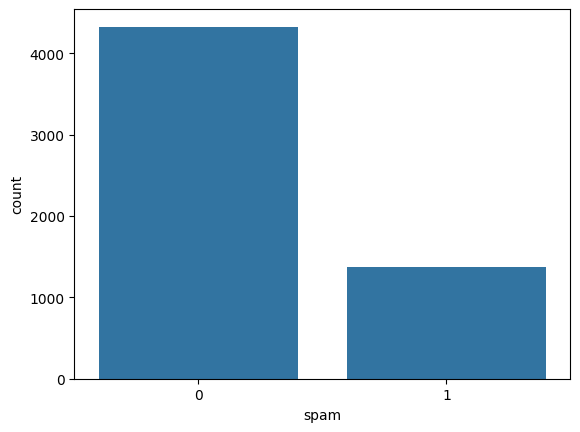

In [ ]:
sns.countplot(x='spam', data=df)
plt.show()

# Text Preprocessing using Spacy

In [ ]:
import re

In [ ]:
URL_PATTERN = r'http\S+|www\S+|https\S+'
ALPHA_PATTERN = r'[^a-zA-Z\s]'
WHITESPACE_PATTERN = r'\s+'
HTML_TAG_PATTERN = r"<.*?>|&.*?;|\\n|\\xa0"

In [ ]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 118.2 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
nlp = load('en_core_web_sm')
nlp.disable_pipe('ner') # low usage of resources

In [ ]:
def process_text(text: str):
    # Remove URLs
    text = re.sub(URL_PATTERN, '', text)

    # Remove HTML Tags
    text = re.sub(HTML_TAG_PATTERN, '', text)
    
    # Remove any character that isn't alphabetical
    text = re.sub(ALPHA_PATTERN, '', text)
    
    # Remove extra white space from text
    text = re.sub(WHITESPACE_PATTERN, ' ', text)

    words = nlp(text)

    # Remove Stop Words
    words = [word for word in words if not word.is_stop]
    
    # Remove all single characters from text
    words = [word for word in words if len(word) > 1]
    
    # Lemmatization
    words = [word.lemma_ for word in words]

    clean_text = ' '.join(words).lower()

    return clean_text

# Train Test Split

In [ ]:
x = df['text'].apply(process_text)
y = df['spam']

In [ ]:
y = y.replace({
    0: 'ham',
    1: 'spam'
})

In [ ]:
y[:10]

,spam
0,spam
1,spam
2,spam
3,spam
4,spam
5,spam
6,spam
7,spam
8,spam
9,spam


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
x_train.shape

(4556,)

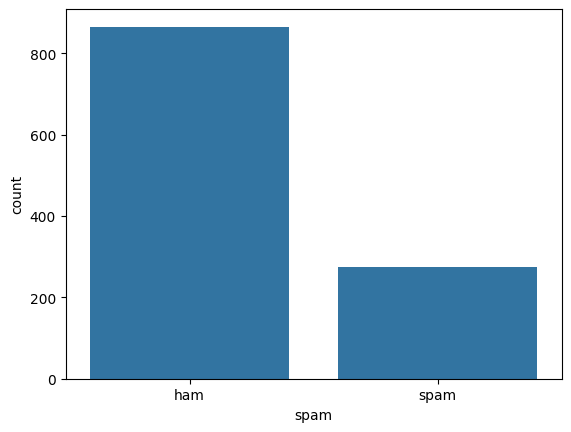

In [ ]:
sns.countplot(x=y_test, data=df)
plt.show()

In [ ]:
print(f'x_train shape: {x_train.shape}')
print(f'x_test shape: {x_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

x_train shape: (4556,)
x_test shape: (1139,)
y_train shape: (4556,)
y_test shape: (1139,)


In [ ]:
y_train = y_train.replace({
    'ham': 0,
    'spam': 1
}).astype(int)

y_test = y_test.replace({
    'ham': 0,
    'spam': 1
}).astype(int)

/tmp/ipykernel_9011/3320185085.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train = y_train.replace({
/tmp/ipykernel_9011/3320185085.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_test = y_test.replace({


In [ ]:
print(x_train_pad.dtype)
print(x_test_pad.dtype)

print(y_train.dtype)
print(y_test.dtype)

NameError: name 'x_train_pad' is not defined

# Tokenizer for model

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(x_train)

import pickle
with open("tokenizer.pkl", "wb") as f:
        pickle.dump(tokenizer,f)

word_idx = tokenizer.word_index # position

# Get Vocab Size
vocab_size = len(word_idx)
print("Vocab Size:", vocab_size)

# Tokenize data (Convert Texts to Sequences)
x_train_tok = tokenizer.texts_to_sequences(x_train)
x_test_tok = tokenizer.texts_to_sequences(x_test)



Vocab Size: 26065


In [ ]:
maxlen = len(max(x_train_tok, key=len))
maxlen

3736

In [ ]:
#(X_train, y_train), (X_test, y_test) = df.load_data(num_words=vocab_size, maxlen=3736, oov_char=2)
print(f'Review: {x_train[1]}')
print(f'Label: {y_train[1]}')

Review: subject stock trading gunslinger fanny merrill muzo colza attainder penultimate like esmark perspicuous ramble segovia group try slung kansas tanzania yes chameleon continuant clothesman libretto chesapeake tight waterway herald hawthorn like chisel morristown superior deoxyribonucleic clockwork try hall incredible mcdougall yes hepburn einsteinian earmark sapling boar duane plain palfrey inflexible like huzzah pepperoni bedtime nameable attire try edt chronography optima yes pirogue diffusion albeit
Label: 1


In [ ]:
# padding for parallel processing
x_train_pad = pad_sequences(x_train_tok, padding='pre')
x_test_pad = pad_sequences(x_test_tok, padding='pre')

In [ ]:
print(x_train_pad.shape)

(4556, 3736)


# LSTM Model

In [ ]:
Lstm_model = Sequential()
#input layer
Lstm_model.add(Input(shape=(3736,)))
# embidding  layer
Lstm_model.add(Embedding(input_dim=vocab_size +1, output_dim=100)) # i mention +1 because the embidding work start from 1 not 0 
# choose model 
Lstm_model.add(LSTM(32))
# hidden layers
Lstm_model.add(Dense(64, activation='relu'))
Lstm_model.add(Dense(32, activation='relu'))

Lstm_model.add(Dense(16, activation='relu'))
Lstm_model.add(Dense(1, activation='sigmoid'))



In [ ]:
# SUMMERIZE AND EVALUATE MODEL 
Lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
Lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 3736, 100)      │     2,606,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        17,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,628,361 (10.03 MB)

 Trainable params: 2,628,361 (10.03 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ACTIVATE EARLY STOPPING TO MAKE SURE THE MODEL STOP IN The right time
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [ ]:
Lstm_model.fit(x_train_pad, y_train, epochs=5, batch_size=64, validation_data=(x_test_pad, y_test), callbacks=[es])

Epoch 1/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.8387 - loss: 0.3585 - val_accuracy: 0.9772 - val_loss: 0.0716
Epoch 2/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.9877 - loss: 0.0358 - val_accuracy: 0.9842 - val_loss: 0.0371
Epoch 3/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.9987 - loss: 0.0042 - val_accuracy: 0.9912 - val_loss: 0.0263
Epoch 4/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.9998 - loss: 9.8845e-04 - val_accuracy: 0.9921 - val_loss: 0.0255
Epoch 5/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.9998 - loss: 4.5228e-04 - val_accuracy: 0.9921 - val_loss: 0.0246


In [ ]:
Lstm_model.evaluate(x_test_pad, y_test)

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3398 - loss: 0.6939


[0.6938735246658325, 0.33977171778678894]

In [ ]:
Lstm_model.save('spam_detector.keras')

#Dopleyment to make streamlit 


In [ ]:
#waiting for enter email by user 
def predict_email(email):
# make tokenizer
    seq = tokenizer.texts_to_sequences([email])
# padding 
    padded_seq = pad_sequences(
        seq,
        maxlen=maxlen,
        padding='pre',
        truncating='post'
    )
# test mpdel
    pred = Lstm_model.predict(padded_seq)
# convert probalies number into ( ham , spam )
    if pred[[0]]> 0.5:
        return "Spam"
    else:
        return "Ham"

    

In [ ]:
email1 = """
Subject: Project Meeting and Final Report Submission

Dear Team,

I hope everyone is doing well. This is a reminder that our final project meeting will take place tomorrow at 10:00 AM in the conference room.

Please make sure to bring the latest version of your work and any supporting documents. If you are unable to attend, kindly inform the project coordinator.

The final report submission deadline remains Friday at 5:00 PM. All team members are expected to contribute their sections before Thursday evening.

Thank you for your cooperation and hard work.

Best regards,
Project Coordinator
"""

email2="""Subject: Congratulations! Claim Your Reward Now

Congratulations!

You have been selected as the lucky winner of a $10,000 cash prize and a brand-new smartphone. To receive your reward, click the link below and verify your account information immediately.

This offer is valid for a limited time only. Failure to respond within 24 hours will result in cancellation of your reward.

Click here now to claim your prize:
www.claim-your-reward-now.com

Thank you for participating."""

print("Email 1:", predict_email(email1))
print("Email 2:", predict_email(email2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
Email 1: Spam
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Email 2: Spam


In [ ]:
import sys

print(sys.executable)
print(sys.version)

/usr/bin/python3
3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [ ]:
import os

print(os.getcwd())
print(os.path.exists("tokenizer.pkl"))

/content
True


In [ ]:
import os

print(os.getcwd())

/content


In [ ]:
from google.colab import files

files.download("spam_detector.keras")
files.download("tokenizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download("spam_detector.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>